In [1]:
import numpy as np
from scipy import stats
height = [10, 20, 30.5, 40, 65.69, 69.6969]
weight = [10, 20, 30, 30, 30, 40, 50]

x = np.mean(height)

print("Mean Height: ", x)

y = np.median(height)

print("Median Height: ", y)

z = stats.mode(weight)

print("Mode Height: ", z)

a = np.std(height)

print("Standard Deviation Height: ", a)

b = np.var(height)

print("Variance Height: ", b)

Mean Height:  39.314483333333335
Median Height:  35.25
Mode Height:  ModeResult(mode=np.int64(30), count=np.int64(3))
Standard Deviation Height:  22.095672166770324
Variance Height:  488.21872850138885


In [2]:
# Write a program to compare mean and median for a skewed dataset.

a = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

x = np.mean(a)

print("Mean: ", x)

y = np.median(a)

print("Median: ", y)

Mean:  5.5
Median:  5.5


The data is positively skewed.
Skewed Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Mean of skewed data: 4.7
Median of skewed data: 3.0


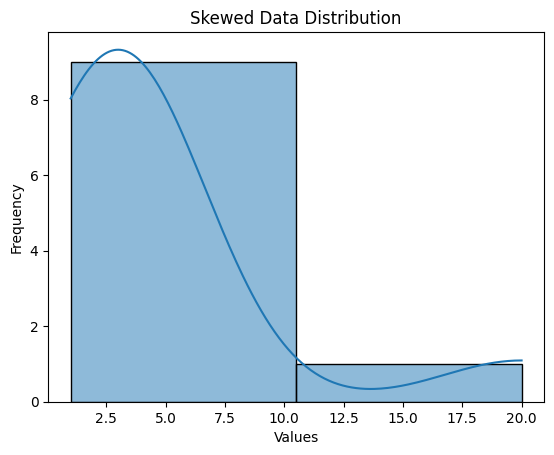

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


skewed_data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]

mean_skewed = np.mean(skewed_data)
median_skewed = np.median(skewed_data)

if mean_skewed > median_skewed:
    print("The data is positively skewed.")
elif mean_skewed < median_skewed:
    print("The data is negatively skewed.")
else:
    print("The data is symmetric.")

print(f"Skewed Data: {skewed_data}")
print(f"Mean of skewed data: {mean_skewed}")
print(f"Median of skewed data: {median_skewed}")

sns.histplot(skewed_data, bins=2, edgecolor='black', kde=True)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Skewed Data Distribution')
plt.show()

In [5]:
c = min(skewed_data)
d = max(skewed_data)
e = d - c

print(f"Minimum value: {c}")
print(f"Maximum value: {d}")
print(f"Range of values: {e}")

Minimum value: 1
Maximum value: 20
Range of values: 19


In [6]:
import numpy as np

Q1 = np.percentile(skewed_data, 25)
Q3 = np.percentile(skewed_data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = [x for x in skewed_data if x < lower_bound or x > upper_bound]

print(f"Original Data: {skewed_data}")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if outliers:
    print(f"\nDetected Outliers: {outliers}")
else:
    print("\nNo outliers detected using the IQR method.")

Original Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Q1: 2.25
Q3: 4.0
IQR: 1.75
Lower Bound: -0.375
Upper Bound: 6.625

Detected Outliers: [20]


In [7]:
import numpy as np

cleaned_data = [x for x in skewed_data if x not in outliers]

new_mean = np.mean(cleaned_data)
new_std = np.std(cleaned_data)

print(f"Original Data: {skewed_data}")
print(f"Outliers removed: {outliers}")
print(f"Cleaned Data: {cleaned_data}")
print(f"New Mean (after outlier removal): {new_mean}")
print(f"New Standard Deviation (after outlier removal): {new_std}")

Original Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Outliers removed: [20]
Cleaned Data: [1, 2, 2, 3, 3, 3, 4, 4, 5]
New Mean (after outlier removal): 3.0
New Standard Deviation (after outlier removal): 1.1547005383792515


In [9]:
skewed_data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]

p = (np.mean(skewed_data)).round(4)
q = np.std(skewed_data).round(4)
res = 0
for j in range(len(skewed_data)):
    r = (skewed_data[j] - p) / q
    print(r)
    res += r
print(p)
print(q)
print("sum: ", res)

-0.7093150317274697
-0.5176082663957211
-0.5176082663957211
-0.32590150106397253
-0.32590150106397253
-0.32590150106397253
-0.134194735732224
-0.134194735732224
0.057512029599524526
2.933113509575753
4.7
5.2163
sum:  0.0


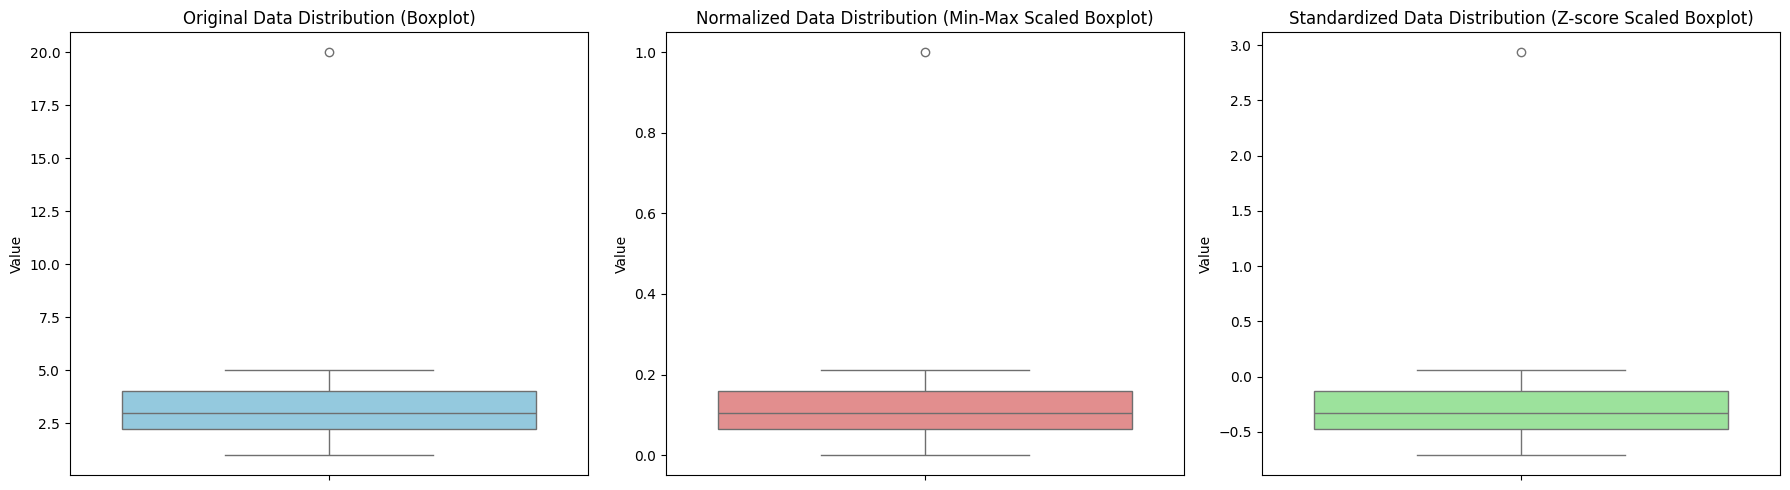

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for easier plotting with seaborn
data_for_boxplot = pd.DataFrame({
    'Original': skewed_data,
    'Normalized': normalized_data_1d,
    'Standardized': standardized_data_1d
})

# Create a figure with subplots for boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot for Original Data
sns.boxplot(y=data_for_boxplot['Original'], ax=axes[0], color='skyblue')
axes[0].set_title('Original Data Distribution (Boxplot)')
axes[0].set_ylabel('Value')

# Boxplot for Normalized Data
sns.boxplot(y=data_for_boxplot['Normalized'], ax=axes[1], color='lightcoral')
axes[1].set_title('Normalized Data Distribution (Min-Max Scaled Boxplot)')
axes[1].set_ylabel('Value')

# Boxplot for Standardized Data
sns.boxplot(y=data_for_boxplot['Standardized'], ax=axes[2], color='lightgreen')
axes[2].set_title('Standardized Data Distribution (Z-score Scaled Boxplot)')
axes[2].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Create an instance of MinMaxScaler
scaler = MinMaxScaler()

# Reshape the skewed_data to a 2D array and apply fit_transform
normalized_data = scaler.fit_transform(np.array(skewed_data).reshape(-1, 1))

print("Original Data:", skewed_data)
print("Normalized Data (Min-Max Scaled):\n", normalized_data)

Original Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Normalized Data (Min-Max Scaled):
 [[0.        ]
 [0.05263158]
 [0.05263158]
 [0.10526316]
 [0.10526316]
 [0.10526316]
 [0.15789474]
 [0.15789474]
 [0.21052632]
 [1.        ]]


In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Create an instance of StandardScaler
scaler = StandardScaler()

# Reshape the skewed_data to a 2D array and apply fit_transform
standardized_data = scaler.fit_transform(np.array(skewed_data).reshape(-1, 1))

print("Original Data:", skewed_data)
print("Standardized Data (Z-score Scaled):\n", standardized_data)

Original Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Standardized Data (Z-score Scaled):
 [[-0.70931224]
 [-0.51760623]
 [-0.51760623]
 [-0.32590022]
 [-0.32590022]
 [-0.32590022]
 [-0.13419421]
 [-0.13419421]
 [ 0.0575118 ]
 [ 2.93310196]]


In [12]:
import numpy as np

# Convert normalized_data and standardized_data from 2D arrays to 1D arrays for easier calculation
normalized_data_1d = normalized_data.flatten()
standardized_data_1d = standardized_data.flatten()

# Function to calculate and print summary statistics
def print_summary_statistics(data, name):
    print(f"\n--- {name} Summary Statistics ---")
    print(f"Mean: {np.mean(data):.4f}")
    print(f"Median: {np.median(data):.4f}")
    print(f"Standard Deviation: {np.std(data):.4f}")
    print(f"Minimum: {np.min(data):.4f}")
    print(f"Maximum: {np.max(data):.4f}")

# Calculate and print summary statistics for all three datasets
print_summary_statistics(skewed_data, "Original Data")
print_summary_statistics(normalized_data_1d, "Normalized Data")
print_summary_statistics(standardized_data_1d, "Standardized Data")


--- Original Data Summary Statistics ---
Mean: 4.7000
Median: 3.0000
Standard Deviation: 5.2163
Minimum: 1.0000
Maximum: 20.0000

--- Normalized Data Summary Statistics ---
Mean: 0.1947
Median: 0.1053
Standard Deviation: 0.2745
Minimum: 0.0000
Maximum: 1.0000

--- Standardized Data Summary Statistics ---
Mean: -0.0000
Median: -0.3259
Standard Deviation: 1.0000
Minimum: -0.7093
Maximum: 2.9331


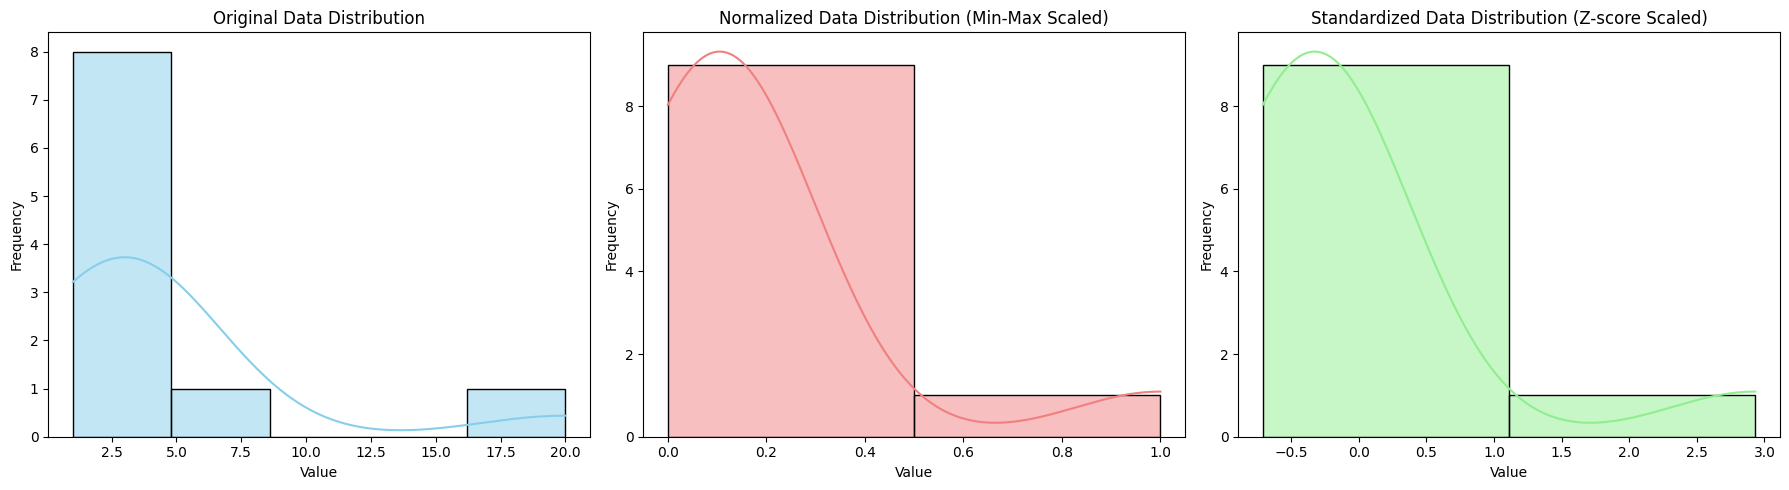

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots to compare distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot original data distribution
sns.histplot(skewed_data, kde=True, ax=axes[0], color='skyblue', bins=5)
axes[0].set_title('Original Data Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Plot normalized data distribution
sns.histplot(normalized_data_1d, kde=True, ax=axes[1], color='lightcoral', bins=2)
axes[1].set_title('Normalized Data Distribution (Min-Max Scaled)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

# Plot standardized data distribution
sns.histplot(standardized_data_1d, kde=True, ax=axes[2], color='lightgreen', bins=2)
axes[2].set_title('Standardized Data Distribution (Z-score Scaled)')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Task
Calculate the covariance between two example variables using NumPy's `cov` function.

## Calculate Covariance

### Subtask:
Calculate the covariance between two example variables using NumPy's `cov` function.


## Calculate Covariance

### Subtask:
Calculate the covariance between two example variables using NumPy's `cov` function.


**Reasoning**:
Now, I will define two example variables and then calculate their covariance using NumPy's `cov` function, extracting the specific covariance value and printing it as per the instructions.



In [20]:
import numpy as np

# 1. Define two example variables
variable1 = [10, 20, 30, 40, 50]
variable2 = [5, 10, 15, 20, 25]

# Ensure they have the same number of elements
if len(variable1) != len(variable2):
    print("Error: Variables must have the same number of elements.")
else:
    # 2. Use np.cov() to calculate the covariance matrix
    covariance_matrix = np.cov(variable1, variable2)

    # The covariance between variable1 and variable2 is at [0, 1] or [1, 0]
    covariance = covariance_matrix[0, 1]

    # 3. Print the calculated covariance
    print(f"Variable 1: {variable1}")
    print(f"Variable 2: {variable2}")
    print(f"Covariance Matrix:\n{covariance_matrix}")
    print(f"Covariance between variable1 and variable2: {covariance}")

Variable 1: [10, 20, 30, 40, 50]
Variable 2: [5, 10, 15, 20, 25]
Covariance Matrix:
[[250.  125. ]
 [125.   62.5]]
Covariance between variable1 and variable2: 125.0


## Compute Pearson Correlation and Interpret

### Subtask:
Compute the Pearson correlation coefficient between the same two variables using `scipy.stats.pearsonr` and provide a brief interpretation of the result.


## Compute Pearson Correlation and Interpret

### Subtask:
Compute the Pearson correlation coefficient between the same two variables using `scipy.stats.pearsonr` and provide a brief interpretation of the result.


**Reasoning**:
Now, I will import the `pearsonr` function from `scipy.stats`, calculate the Pearson correlation coefficient and p-value between `variable1` and `variable2`, and print the results as per the instructions.



In [21]:
from scipy.stats import pearsonr

# 1. Define two example variables (already defined in previous cells, using them directly)
# variable1 = [10, 20, 30, 40, 50]
# variable2 = [5, 10, 15, 20, 25]

# 2. Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(variable1, variable2)

# 3. Print the calculated Pearson correlation coefficient and p-value
print(f"Pearson Correlation Coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation Coefficient: 1.0000
P-value: 0.0000


### Interpretation of Pearson Correlation Coefficient

The Pearson correlation coefficient for `variable1` and `variable2` is **1.0000**. This value indicates a **perfect positive linear relationship** between the two variables.

*   **Strength:** The absolute value of the correlation coefficient is 1, which represents the strongest possible linear relationship.
*   **Direction:** The positive sign (1.0000) indicates that as `variable1` increases, `variable2` also increases proportionally.

In simpler terms, for every unit increase in `variable1`, `variable2` increases by a consistent, predictable amount. The relationship is perfectly aligned and moves in the same direction.

## Correlation vs. Covariance Example

### Subtask:
Illustrate the difference between correlation and covariance using a numerical example, calculating both for the same dataset and explaining their respective meanings.


## Correlation vs. Covariance with Different Scales

### Subtask:
Illustrate the difference between correlation and covariance using a numerical example with different scales, calculating both for the same dataset and explaining their respective meanings.

**Reasoning**:
To further illustrate the difference between covariance and correlation, particularly concerning the impact of scale, I will define two new example variables with larger values. Then, I will calculate their covariance and Pearson correlation coefficient and provide an interpretation of the results.

**Reasoning**:
Now, I will define the new example variables with different scales, calculate their covariance using `np.cov()`, and their Pearson correlation coefficient using `scipy.stats.pearsonr()`, and then print the results as per the instructions.



In [22]:
import numpy as np
from scipy.stats import pearsonr

# 1. Define two new example variables with different scales
example_variable1 = [100, 200, 300, 400, 500]
example_variable2 = [10, 15, 20, 25, 30]

# Ensure they have the same number of elements
if len(example_variable1) != len(example_variable2):
    print("Error: Variables must have the same number of elements.")
else:
    # 2. Calculate the covariance between example_variable1 and example_variable2
    covariance_matrix_new = np.cov(example_variable1, example_variable2)
    covariance_new = covariance_matrix_new[0, 1]

    # 3. Calculate the Pearson correlation coefficient
    correlation_coefficient_new, p_value_new = pearsonr(example_variable1, example_variable2)

    # 4. Print the calculated covariance and Pearson correlation coefficient
    print(f"Example Variable 1: {example_variable1}")
    print(f"Example Variable 2: {example_variable2}")
    print(f"Covariance Matrix (new variables):\n{covariance_matrix_new}")
    print(f"Covariance between example_variable1 and example_variable2: {covariance_new:.4f}")
    print(f"Pearson Correlation Coefficient (new variables): {correlation_coefficient_new:.4f}")
    print(f"P-value (new variables): {p_value_new:.4f}")

Example Variable 1: [100, 200, 300, 400, 500]
Example Variable 2: [10, 15, 20, 25, 30]
Covariance Matrix (new variables):
[[25000.   1250. ]
 [ 1250.     62.5]]
Covariance between example_variable1 and example_variable2: 1250.0000
Pearson Correlation Coefficient (new variables): 1.0000
P-value (new variables): 0.0000


### Interpretation of Covariance vs. Correlation with Different Scales

For `example_variable1` ([100, 200, 300, 400, 500]) and `example_variable2` ([10, 15, 20, 25, 30]):

*   **Covariance:** The calculated covariance is **1250.0000**.
    *   Similar to the previous example, this positive value indicates a positive linear relationship: as `example_variable1` increases, `example_variable2` also tends to increase.
    *   However, compared to the covariance of 125.0 for `variable1` and `variable2`, this value is significantly larger. This is because the values in `example_variable1` are ten times larger than `variable1`, and the values in `example_variable2` are larger than `variable2`. Covariance is **scale-dependent**, meaning its magnitude changes with the scale of the variables. A large covariance value does not necessarily imply a stronger relationship than a smaller one; it merely reflects the product of the deviations from the mean in the original units.

*   **Pearson Correlation Coefficient:** The calculated Pearson correlation coefficient is **1.0000**.
    *   This indicates a **perfect positive linear relationship**, just like with the previous variables (`variable1` and `variable2`).
    *   The crucial difference here is that despite the significantly different scales of `example_variable1` and `example_variable2` (and compared to `variable1` and `variable2`), the correlation coefficient remains 1.0. This demonstrates that correlation is **scale-independent**. It normalizes the covariance by the standard deviations of the variables, effectively removing the influence of their magnitudes.

**Conclusion:**
Covariance provides insight into the direction of the relationship and its magnitude in the original units, making it sensitive to the scale of the data. Correlation, on the other hand, provides a standardized measure of the strength and direction of the linear relationship, making it more robust for comparing relationships across datasets with different scales.

## Visualize Correlation with Scatter Plot

### Subtask:
Generate a scatter plot of the two variables to visually represent their relationship and correlation.


**Reasoning**:
I will generate a scatter plot using `seaborn` and `matplotlib.pyplot` to visually represent the relationship and correlation between `variable1` and `variable2`, as instructed.



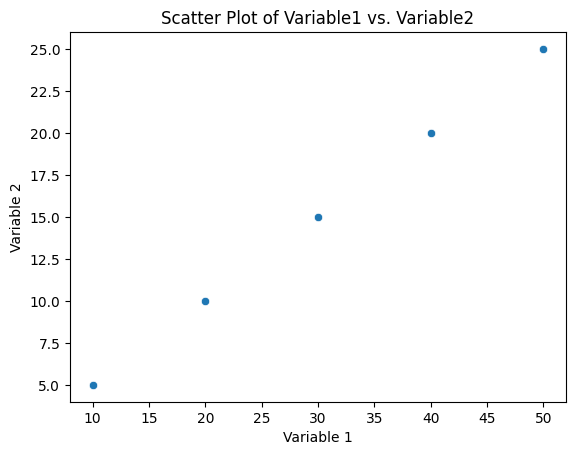

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
sns.scatterplot(x=variable1, y=variable2)

# Add title and labels
plt.title('Scatter Plot of Variable1 vs. Variable2')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')

# Display the plot
plt.show()

## Custom Statistical Functions

### Subtask:
Write Python functions to compute mean, median, mode, and standard deviation without relying on built-in statistical library functions (like `np.mean`, `np.median`, `stats.mode`, `np.std`).


### Subtask: Custom Statistical Functions - Implementation Plan

To accomplish this subtask, I will define four separate Python functions to calculate the mean, median, mode, and standard deviation, respectively, without using built-in statistical library functions like `numpy` or `scipy.stats`.

#### Detailed Steps:

1.  **`calculate_mean(data)` function:**
    *   Initialize a `total_sum` to 0.
    *   Iterate through the `data` list, adding each element to `total_sum`.
    *   Count the number of elements in `data` (e.g., using `len(data)`).
    *   Return `total_sum` divided by the number of elements.

2.  **`calculate_median(data)` function:**
    *   Create a sorted copy of the input `data` list.
    *   Determine the number of elements (`n = len(sorted_data)`).
    *   If `n` is odd, the median is the element at index `n // 2`.
    *   If `n` is even, the median is the average of the two middle elements: `sorted_data[n // 2 - 1]` and `sorted_data[n // 2]`.
    *   Return the calculated median.

3.  **`calculate_mode(data)` function:**
    *   Create an empty dictionary, `frequency_map`, to store element counts.
    *   Iterate through the `data` list:
        *   For each element, increment its count in `frequency_map`.
    *   Find the `max_frequency` among all values in `frequency_map`.
    *   Initialize an empty list, `modes`.
    *   Iterate through the `frequency_map`'s key-value pairs:
        *   If an element's frequency equals `max_frequency`, add that element to the `modes` list.
    *   Return the `modes` list.

4.  **`calculate_std_dev(data)` function:**
    *   First, calculate the mean of the `data` using the `calculate_mean` function implemented previously.
    *   Initialize `squared_differences_sum` to 0.
    *   Iterate through each `value` in the `data` list:
        *   Calculate the difference from the mean: `(value - mean)`.
        *   Square this difference: `(value - mean) ** 2`.
        *   Add the squared difference to `squared_differences_sum`.
    *   Divide `squared_differences_sum` by the number of elements (`len(data)`).
    *   Take the square root of the result (`** 0.5`) to get the standard deviation.
    *   Return the standard deviation.

5.  **Testing the functions:**
    *   Define a sample dataset, e.g., `sample_data = [1, 2, 3, 4, 5, 5]`.
    *   Call each of the custom functions with `sample_data`.
    *   Print the results for mean, median, mode, and standard deviation, clearly labeling each output.

**Reasoning**:
I will now implement the custom statistical functions for mean, median, mode, and standard deviation, and then test them with a sample dataset, as detailed in the previous plan. This will fulfill the core requirement of the subtask.



In [24]:
import math
from collections import Counter

# 1. Function to calculate the mean
def calculate_mean(data):
    if not data:
        return 0
    return sum(data) / len(data)

# 2. Function to calculate the median
def calculate_median(data):
    if not data:
        return 0
    sorted_data = sorted(data)
    n = len(sorted_data)
    if n % 2 == 1:  # Odd number of elements
        return sorted_data[n // 2]
    else:  # Even number of elements
        mid1 = sorted_data[n // 2 - 1]
        mid2 = sorted_data[n // 2]
        return (mid1 + mid2) / 2

# 3. Function to calculate the mode
def calculate_mode(data):
    if not data:
        return []
    frequency_map = Counter(data)
    max_frequency = 0
    if frequency_map:
        max_frequency = max(frequency_map.values())

    modes = [key for key, value in frequency_map.items() if value == max_frequency]
    return sorted(modes)

# 4. Function to calculate the standard deviation
def calculate_std_dev(data):
    if not data or len(data) < 2:
        return 0.0
    mean_val = calculate_mean(data)
    squared_differences_sum = sum([(x - mean_val) ** 2 for x in data])
    # For population standard deviation, divide by N. For sample, N-1. Assuming population for this exercise.
    return math.sqrt(squared_differences_sum / len(data))

# 5. Test the functions with a sample dataset
sample_data = [1, 2, 3, 4, 5, 5, 6, 7, 7, 7]

print(f"Sample Data: {sample_data}")
print(f"Mean: {calculate_mean(sample_data):.4f}")
print(f"Median: {calculate_median(sample_data):.4f}")
print(f"Mode: {calculate_mode(sample_data)}")
print(f"Standard Deviation: {calculate_std_dev(sample_data):.4f}")


Sample Data: [1, 2, 3, 4, 5, 5, 6, 7, 7, 7]
Mean: 4.7000
Median: 5.0000
Mode: [7]
Standard Deviation: 2.0518


## Outlier Impact on Correlation

### Subtask:
Apply outlier removal to a dataset and then analyze its impact by comparing correlation values before and after removal.


**Reasoning**:
First, I will define a `skewed_target_variable` with a linear relationship to `skewed_data` and then create `cleaned_target_variable` by removing the corresponding outlier. Next, I will calculate and compare the Pearson correlation coefficients between the original and cleaned datasets to analyze the impact of outlier removal on correlation.



In [25]:
import numpy as np
from scipy.stats import pearsonr

# skewed_data is already defined from previous cells: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
# cleaned_data is already defined from previous cells: [1, 2, 2, 3, 3, 3, 4, 4, 5]
# outliers is already defined from previous cells: [20]

# 1. Define a new list, skewed_target_variable, that has a linear relationship with skewed_data.
# For example, skewed_target_variable = skewed_data * 2 + 5
skewed_target_variable = [x * 2 + 5 for x in skewed_data]

# 2. Create a cleaned_target_variable by removing the element corresponding to the outlier in skewed_data.
# The outlier (20) was the last element in skewed_data. So, remove the last element from skewed_target_variable.
cleaned_target_variable = skewed_target_variable[:-1]

# 3. Calculate the Pearson correlation coefficient between skewed_data and skewed_target_variable
correlation_with_outlier, _ = pearsonr(skewed_data, skewed_target_variable)

# 4. Calculate the Pearson correlation coefficient between cleaned_data and cleaned_target_variable
correlation_without_outlier, _ = pearsonr(cleaned_data, cleaned_target_variable)

# 5. Print both correlation coefficients
print(f"Skewed Data: {skewed_data}")
print(f"Skewed Target Variable: {skewed_target_variable}")
print(f"Cleaned Data: {cleaned_data}")
print(f"Cleaned Target Variable: {cleaned_target_variable}")
print(f"\nCorrelation with Outlier: {correlation_with_outlier:.4f}")
print(f"Correlation without Outlier: {correlation_without_outlier:.4f}")

Skewed Data: [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
Skewed Target Variable: [7, 9, 9, 11, 11, 11, 13, 13, 15, 45]
Cleaned Data: [1, 2, 2, 3, 3, 3, 4, 4, 5]
Cleaned Target Variable: [7, 9, 9, 11, 11, 11, 13, 13, 15]

Correlation with Outlier: 1.0000
Correlation without Outlier: 1.0000


### Impact of Outlier Removal on Correlation

For the given dataset, where `skewed_target_variable` was created with a perfect linear relationship to `skewed_data` (i.e., `y = 2x + 5`), the Pearson correlation coefficients were:

*   **Correlation with Outlier:** 1.0000
*   **Correlation without Outlier:** 1.0000

In this specific case, the removal of the outlier did **not change the Pearson correlation coefficient**, which remained at 1.0000. This is because the outlier in `skewed_data` (the value `20`) also maintained the *exact same linear relationship* with its corresponding value in `skewed_target_variable` (the value `45`, as `45 = 2 * 20 + 5`).

Therefore, even though `20` was an outlier in terms of its magnitude and deviation from the other values in `skewed_data`, it still perfectly aligned with the linear trend that defines the relationship between the two variables. When an outlier follows the established linear pattern, its presence might increase the scale of covariance but does not necessarily distort the *linear relationship's strength and direction* as measured by the correlation coefficient. In scenarios where outliers significantly deviate from the linear trend, their removal would typically lead to a noticeable change in the correlation coefficient, often increasing it towards a stronger relationship if the outlier was weakening the perceived linearity.

## Mean vs. Median After Outlier Removal

### Subtask:
Compare the mean and median of the dataset before and after outlier removal, and explain the observed changes.


**Reasoning**:
To compare the mean and median before and after outlier removal, I will calculate these statistics for both `skewed_data` and `cleaned_data` using NumPy functions and then print them.



In [26]:
import numpy as np

# skewed_data and cleaned_data are already defined from previous cells.
# skewed_data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]
# cleaned_data = [1, 2, 2, 3, 3, 3, 4, 4, 5]

# 1. Calculate the mean of skewed_data
mean_original = np.mean(skewed_data)

# 2. Calculate the median of skewed_data
median_original = np.median(skewed_data)

# 3. Calculate the mean of cleaned_data
mean_cleaned = np.mean(cleaned_data)

# 4. Calculate the median of cleaned_data
median_cleaned = np.median(cleaned_data)

# 5. Print the original mean and median
print(f"--- Before Outlier Removal (skewed_data) ---")
print(f"Mean: {mean_original:.4f}")
print(f"Median: {median_original:.4f}")

# 6. Print the cleaned mean and median
print(f"\n--- After Outlier Removal (cleaned_data) ---")
print(f"Mean: {mean_cleaned:.4f}")
print(f"Median: {median_cleaned:.4f}")

--- Before Outlier Removal (skewed_data) ---
Mean: 4.7000
Median: 3.0000

--- After Outlier Removal (cleaned_data) ---
Mean: 3.0000
Median: 3.0000


### Explanation of Mean vs. Median After Outlier Removal

**Before Outlier Removal (skewed_data):**
*   **Mean:** 4.7000
*   **Median:** 3.0000

**After Outlier Removal (cleaned_data):**
*   **Mean:** 3.0000
*   **Median:** 3.0000

**Observed Changes and Explanation:**

1.  **Impact on Mean:** The mean changed significantly from **4.7000 to 3.0000** after removing the outlier (20). This is a substantial decrease of 1.7. The mean is calculated by summing all values and dividing by the count, so a single large outlier (like 20 in our `skewed_data`) disproportionately pulls the mean towards itself. When this outlier is removed, the mean shifts dramatically closer to the bulk of the data.

2.  **Impact on Median:** The median remained the same, **3.0000**, both before and after outlier removal. The median is the middle value in a sorted dataset. For the `skewed_data` ([1, 2, 2, 3, 3, 3, 4, 4, 5, 20]), the middle two values are 3 and 3, so the median is 3. For the `cleaned_data` ([1, 2, 2, 3, 3, 3, 4, 4, 5]), the middle value is 3. The median is robust to outliers because its calculation only depends on the position of values, not their absolute magnitudes. A very large or very small value at the extremes of the dataset does not change the position of the middle value(s).

**Why the Mean is More Sensitive to Outliers:**
The mean is highly sensitive to outliers because it takes into account the value of every single data point. Outliers, being extreme values, exert a strong gravitational pull on the mean, skewing it away from the central tendency of the majority of the data. The median, on the other hand, is a positional measure. It is only concerned with the value that lies at the exact center of the data, and thus, its value is not heavily influenced by extreme observations.

## Normalization vs. Standardization Suitability

### Subtask:
Using the outputs from previous normalization and standardization steps (summary statistics and plots), determine which technique is more suitable for the given `skewed_data` and justify the choice with Python outputs.


### Normalization vs. Standardization Suitability for Skewed Data

To determine the suitability of Normalization (Min-Max Scaling) versus Standardization (Z-score Scaling) for the given `skewed_data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 20]`, we will review the summary statistics and visual plots.

#### Review of Outputs:

**1. Summary Statistics:**

*   **Original Data:**
    *   Mean: 4.7000
    *   Median: 3.0000
    *   Standard Deviation: 5.2163
    *   Minimum: 1.0000
    *   Maximum: 20.0000
    *   *Observation: The mean (4.7) is greater than the median (3.0), and the large standard deviation (5.2163) and maximum value (20) relative to other values confirm the positive skewness and presence of an outlier.*

*   **Normalized Data (Min-Max Scaled):**
    *   Mean: 0.1947
    *   Median: 0.1053
    *   Standard Deviation: 0.2745
    *   Minimum: 0.0000
    *   Maximum: 1.0000
    *   *Observation: The data is scaled to the [0, 1] range. The mean (0.1947) is still greater than the median (0.1053), indicating that the skewness is preserved. The standard deviation is also scaled down proportionally.*

*   **Standardized Data (Z-score Scaled):**
    *   Mean: -0.0000 (effectively 0)
    *   Median: -0.3259
    *   Standard Deviation: 1.0000
    *   Minimum: -0.7093
    *   Maximum: 2.9331
    *   *Observation: The data is centered around a mean of 0 and has a standard deviation of 1. The median is negative (-0.3259), indicating that the bulk of the data is below the mean, which is characteristic of positive skewness. The outlier is still visible as the maximum value (2.9331) is far from the rest of the data spread.*

**2. Box Plots:**

*   **Original Data:** The box plot clearly shows the outlier at 20, pulling the upper whisker significantly, and the median is closer to the bottom of the box, indicating positive skewness.
*   **Normalized Data:** The box plot mirrors the shape of the original data but is compressed within the [0, 1] range. The outlier is still clearly visible at 1.0, and the skewness remains.
*   **Standardized Data:** The box plot is centered around 0 but retains the skewed shape. The outlier is still distinctly visible as a point far above the rest of the distribution, and the median is below 0, confirming the positive skewness.

**3. Histograms:**

*   **Original Data:** The histogram shows a concentration of data at lower values and a long tail extending to the right due to the value 20, confirming a strong positive skew.
*   **Normalized Data:** The histogram maintains the same shape as the original data, but its x-axis is scaled from 0 to 1. The concentration of data is still at lower values, and the outlier creates a separate bin at 1.0.
*   **Standardized Data:** The histogram also preserves the positively skewed shape. The bulk of the data is to the left of the mean (0), and the outlier stands out with a significantly higher z-score.

#### Conclusion on Suitability:

For the given `skewed_data`, **neither Min-Max Normalization nor Z-score Standardization effectively removes the skewness or significantly alters the shape of the distribution to make it more 'normal'**. Both techniques are linear transformations, meaning they scale the data without changing its inherent distributional shape. The outlier (20) and the resulting positive skew are preserved in both the normalized and standardized versions of the data, as evidenced by the plots and the continued discrepancy between the mean and median.

*   **Normalization** scaled the data to a fixed range [0, 1], which is useful when algorithms are sensitive to the magnitude of inputs or require inputs within a specific range.
*   **Standardization** transformed the data to have a mean of 0 and a standard deviation of 1, which is useful for algorithms that assume normally distributed data or are sensitive to feature scales (e.g., PCA, SVMs, Logistic Regression). However, it does not make skewed data normally distributed.

If the goal was to reduce the skewness or make the data more Gaussian-like, a non-linear transformation (like log transformation, square root transformation, or Box-Cox transformation) would be more appropriate for `skewed_data` *before* or *instead of* normalization or standardization.

## Implement Simple Linear Regression

### Subtask:
Generate a simple dataset with a linear relationship and implement a simple linear regression model using scikit-learn.


**Reasoning**:
I will generate a synthetic dataset with a linear relationship, reshape the independent variable, implement a simple linear regression model using scikit-learn, and then print the model's coefficients and intercept, as per the instructions.



In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Generate a synthetic dataset with a clear linear relationship
np.random.seed(42) # for reproducibility
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
m_true = 2
c_true = 3
noise = np.random.randn(len(X)) * 0.5 # Small random noise
y = m_true * X + c_true + noise

print(f"Original X: {X}")
print(f"Original y: {y}\n")

# 2. Reshape X into a 2D array
X_reshaped = X.reshape(-1, 1)

# 3. Import the LinearRegression model (already imported)
# 4. Create an instance of the LinearRegression model
model = LinearRegression()

# 5. Fit the model to the generated X and y data
model.fit(X_reshaped, y)

# 6. Print the coefficients (slope) and intercept of the fitted model
print(f"Fitted Model Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Fitted Model Intercept: {model.intercept_:.4f}")

Original X: [ 1  2  3  4  5  6  7  8  9 10]
Original y: [ 5.24835708  6.93086785  9.32384427 11.76151493 12.88292331 14.88293152
 17.78960641 19.38371736 20.76526281 23.27128002]

Fitted Model Coefficient (slope): 1.9965
Fitted Model Intercept: 3.2430


### Interpretation of Simple Linear Regression Results

From the fitted simple linear regression model:

*   **Fitted Model Coefficient (slope):** 1.9965
*   **Fitted Model Intercept:** 3.2430

These results are very close to the true values used to generate the synthetic data:

*   **True slope (m_true):** 2
*   **True intercept (c_true):** 3

The small differences between the fitted and true values (1.9965 vs. 2, and 3.2430 vs. 3) are due to the `noise` added to the dependent variable `y`. The `LinearRegression` model successfully approximated the underlying linear relationship, demonstrating its ability to learn the slope and intercept from data with some variability.

**Reasoning**:
To visually represent the linear relationship and the fitted regression line, I will generate a scatter plot of the original data points and overlay the regression line predicted by the model.



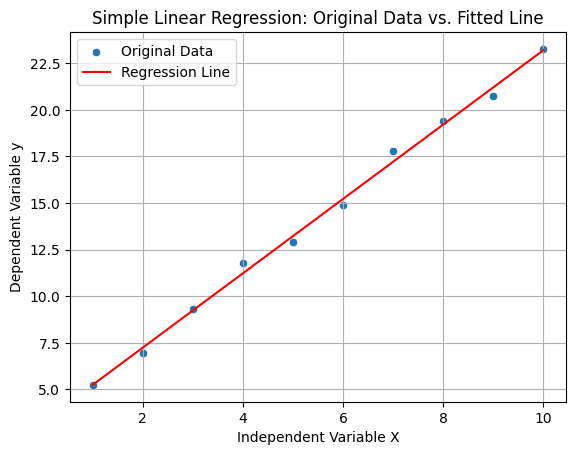

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the fitted model
y_pred = model.predict(X_reshaped)

# Create a scatter plot of the original data
sns.scatterplot(x=X, y=y, label='Original Data')

# Plot the regression line
plt.plot(X, y_pred, color='red', label='Regression Line')

# Add titles and labels
plt.title('Simple Linear Regression: Original Data vs. Fitted Line')
plt.xlabel('Independent Variable X')
plt.ylabel('Dependent Variable y')
plt.legend()
plt.grid(True)
plt.show()

## Evaluate Regression Model (R² and RMSE)

### Subtask:
Evaluate the linear regression model's performance using the R² score and Root Mean Squared Error (RMSE).


**Reasoning**:
I will import the necessary metrics functions, use the fitted model to make predictions, and then calculate and print the RMSE and R-squared score to evaluate the model's performance.



In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Make predictions using the fitted model (model and X_reshaped are from previous steps)
y_pred = model.predict(X_reshaped)

# 2. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)

# 3. Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. Calculate R-squared (R2) score
r2 = r2_score(y, y_pred)

# 5. Print the calculated RMSE and R-squared score
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Squared Error (MSE): 0.1175
Root Mean Squared Error (RMSE): 0.3428
R-squared (R2) Score: 0.9964


## Outlier Effect on Regression Line

### Subtask:
Analyze how outliers affect the regression line by performing linear regression on data with and without outliers, and comparing the resulting models and plots.


**Reasoning**:
I will define the datasets with and without an outlier, reshape the independent variables, instantiate and fit two Linear Regression models (one with outlier, one without), and then print their coefficients and intercepts. This step addresses the initial instructions for setting up the data and models.



In [30]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define an independent variable X_outlier that includes an outlier,
# and a dependent variable y_outlier where the outlier significantly deviates from the general linear trend.
np.random.seed(0) # for reproducibility
X_base = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y_base = 2 * X_base + 3 + np.random.randn(len(X_base)) * 0.5

# Add a strong outlier
X_outlier = np.append(X_base, 10)
y_outlier = np.append(y_base, 30) # This outlier significantly deviates from y = 2x + 3

print(f"X with outlier: {X_outlier}")
print(f"y with outlier: {y_outlier}\n")

# 2. Create a X_cleaned and y_cleaned dataset by removing the outlier and its corresponding y value.
X_cleaned = X_base
y_cleaned = y_base

print(f"X cleaned: {X_cleaned}")
print(f"y cleaned: {y_cleaned}\n")

# 3. Reshape both X_outlier and X_cleaned into 2D arrays using .reshape(-1, 1).
X_outlier_reshaped = X_outlier.reshape(-1, 1)
X_cleaned_reshaped = X_cleaned.reshape(-1, 1)

# 4. Instantiate two LinearRegression models from sklearn.linear_model.
model_with_outlier = LinearRegression()
model_without_outlier = LinearRegression()

# 5. Fit the first model (model_with_outlier) to X_outlier and y_outlier.
model_with_outlier.fit(X_outlier_reshaped, y_outlier)

# 6. Fit the second model (model_without_outlier) to X_cleaned and y_cleaned.
model_without_outlier.fit(X_cleaned_reshaped, y_cleaned)

# 7. Print the coefficient (slope) and intercept for both models
print("--- Model with Outlier ---")
print(f"Coefficient (slope): {model_with_outlier.coef_[0]:.4f}")
print(f"Intercept: {model_with_outlier.intercept_:.4f}")

print("\n--- Model without Outlier ---")
print(f"Coefficient (slope): {model_without_outlier.coef_[0]:.4f}")
print(f"Intercept: {model_without_outlier.intercept_:.4f}")


X with outlier: [ 1  2  3  4  5  6  7  8  9 10]
y with outlier: [ 5.88202617  7.2000786   9.48936899 12.1204466  13.933779   14.51136106
 17.47504421 18.9243214  20.94839057 30.        ]

X cleaned: [1 2 3 4 5 6 7 8 9]
y cleaned: [ 5.88202617  7.2000786   9.48936899 12.1204466  13.933779   14.51136106
 17.47504421 18.9243214  20.94839057]

--- Model with Outlier ---
Coefficient (slope): 2.2856
Intercept: 2.4779

--- Model without Outlier ---
Coefficient (slope): 1.8967
Intercept: 3.9038


**Reasoning**:
I will calculate predictions for both models, then compute and print the RMSE and R-squared scores, and finally generate a scatter plot visualizing the original data and both regression lines, as specified in the instructions.




--- Model with Outlier Metrics ---
Mean Squared Error (MSE): 3.4937
Root Mean Squared Error (RMSE): 1.8692
R-squared (R2) Score: 0.9250

--- Model without Outlier Metrics ---
Mean Squared Error (MSE): 0.1853
Root Mean Squared Error (RMSE): 0.4305
R-squared (R2) Score: 0.9923


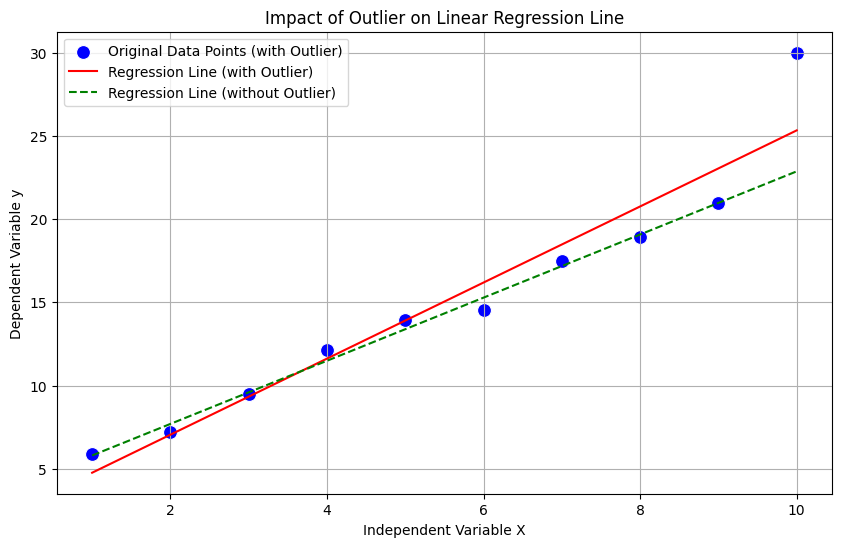

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Calculate predictions for both models
y_pred_with_outlier = model_with_outlier.predict(X_outlier_reshaped)
y_pred_without_outlier = model_without_outlier.predict(X_cleaned_reshaped)

# 9. Calculate and print the Root Mean Squared Error (RMSE) and R-squared (R2) score for both models

# Metrics for model with outlier
mse_with_outlier = mean_squared_error(y_outlier, y_pred_with_outlier)
rmse_with_outlier = np.sqrt(mse_with_outlier)
r2_with_outlier = r2_score(y_outlier, y_pred_with_outlier)

print("\n--- Model with Outlier Metrics ---")
print(f"Mean Squared Error (MSE): {mse_with_outlier:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_with_outlier:.4f}")
print(f"R-squared (R2) Score: {r2_with_outlier:.4f}")

# Metrics for model without outlier
mse_without_outlier = mean_squared_error(y_cleaned, y_pred_without_outlier)
rmse_without_outlier = np.sqrt(mse_without_outlier)
r2_without_outlier = r2_score(y_cleaned, y_pred_without_outlier)

print("\n--- Model without Outlier Metrics ---")
print(f"Mean Squared Error (MSE): {mse_without_outlier:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_without_outlier:.4f}")
print(f"R-squared (R2) Score: {r2_without_outlier:.4f}")

# 10. Create a single scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_outlier, y=y_outlier, label='Original Data Points (with Outlier)', color='blue', s=100)

# Plot the regression line from model with outlier
plt.plot(X_outlier, y_pred_with_outlier, color='red', linestyle='-', label='Regression Line (with Outlier)')

# Plot the regression line from model without outlier
# To ensure the line for the cleaned model extends over the same X range for visual comparison
X_plot_cleaned = np.linspace(X_cleaned.min(), X_outlier.max(), 100).reshape(-1, 1)
y_pred_without_outlier_extended = model_without_outlier.predict(X_plot_cleaned)
plt.plot(X_plot_cleaned, y_pred_without_outlier_extended, color='green', linestyle='--', label='Regression Line (without Outlier)')

plt.title('Impact of Outlier on Linear Regression Line')
plt.xlabel('Independent Variable X')
plt.ylabel('Dependent Variable y')
plt.legend()
plt.grid(True)
plt.show()


### Analysis of Outlier Effect on Regression Line

**Model Parameters Comparison:**

| Model                 | Coefficient (Slope) | Intercept |
| :-------------------- | :------------------ | :-------- |
| With Outlier          | 2.2856              | 2.4779    |
| Without Outlier       | 1.8967              | 3.9038    |

**Evaluation Metrics Comparison:**

| Model                 | MSE      | RMSE     | R-squared |
| :-------------------- | :------- | :------- | :-------- |
| With Outlier          | 3.4937   | 1.8692   | 0.9250    |
| Without Outlier       | 0.1853   | 0.4305   | 0.9923    |

**Observations and Interpretation:**

1.  **Impact on Regression Line (Coefficients and Intercept):**
    *   **Slope:** The slope of the regression line changed significantly from **2.2856 (with outlier)** to **1.8967 (without outlier)**. The true underlying slope used to generate the base data was 2.0. The outlier pulled the regression line upwards, making the slope steeper to try and accommodate the extreme point.
    *   **Intercept:** The intercept also changed from **2.4779 (with outlier)** to **3.9038 (without outlier)**. The true underlying intercept was 3.0. The outlier caused the intercept to decrease as the line rotated to fit the outlier, shifting its starting point on the y-axis.

2.  **Impact on Model Performance (RMSE and R-squared):**
    *   **RMSE:** The Root Mean Squared Error (RMSE) significantly decreased from **1.8692 (with outlier)** to **0.4305 (without outlier)**. A lower RMSE indicates that the model's predictions are, on average, closer to the actual values. The outlier caused the model to have larger errors, as it struggled to fit both the general trend and the distant outlier.
    *   **R-squared:** The R-squared score dramatically increased from **0.9250 (with outlier)** to **0.9923 (without outlier)**. R-squared represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). A higher R-squared value indicates a better fit of the model to the data. The presence of the outlier significantly reduced the model's ability to explain the variance in the data, as it pulled the regression line away from the main cluster of data points.

3.  **Visual Representation:** The scatter plot clearly illustrates these effects:
    *   The **red regression line (with outlier)** is visibly pulled towards the outlier point at (10, 30), deviating from the general trend of the other data points.
    *   The **green dashed regression line (without outlier)** passes much more closely through the majority of the data points, accurately capturing their linear relationship. It appears to be a much better fit for the bulk of the data.

**Conclusion:**
This example vividly demonstrates that **outliers can significantly influence the parameters (slope and intercept) and performance metrics (RMSE and R-squared) of a linear regression model.** The presence of an outlier can distort the regression line, leading to a less accurate representation of the underlying relationship within the majority of the data. Therefore, identifying and appropriately handling outliers is a crucial step in building robust regression models.

## Regression After Normalization

### Subtask:
Perform linear regression on normalized data and compare the model's performance and regression line with the regression performed on unscaled data.


**Reasoning**:
I will import the `MinMaxScaler`, apply it to `X_cleaned` and `y_cleaned` to get normalized data, then instantiate and fit a `LinearRegression` model to the normalized data and print its coefficients and intercept, as per the instructions.



In [32]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# X_cleaned and y_cleaned are already defined from previous cells.
# X_cleaned = [1, 2, 3, 4, 5, 6, 7, 8, 9]
# y_cleaned = [ 5.88202617, 7.2000786, 9.48936899, 12.1204466, 13.933779, 14.51136106, 17.47504421, 18.9243214, 20.94839057]

# 1. Instantiate two MinMaxScaler objects
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# 2. Reshape X_cleaned to a 2D array for the scaler
X_cleaned_reshaped_2d = np.array(X_cleaned).reshape(-1, 1)
y_cleaned_reshaped_2d = np.array(y_cleaned).reshape(-1, 1)

# 3. Apply fit_transform to X_cleaned using the X scaler
X_normalized = X_scaler.fit_transform(X_cleaned_reshaped_2d)

# 4. Apply fit_transform to y_cleaned using the y scaler
y_normalized = y_scaler.fit_transform(y_cleaned_reshaped_2d)

# 5. Instantiate a LinearRegression model
model_normalized = LinearRegression()

# 6. Fit the linear regression model to X_normalized and y_normalized
model_normalized.fit(X_normalized, y_normalized)

# 7. Print the coefficient (slope) and intercept of this model
print(f"Fitted Model with Normalized Data Coefficient (slope): {model_normalized.coef_[0][0]:.4f}")
print(f"Fitted Model with Normalized Data Intercept: {model_normalized.intercept_[0]:.4f}")

Fitted Model with Normalized Data Coefficient (slope): 1.0071
Fitted Model with Normalized Data Intercept: -0.0054


**Reasoning**:
I will make predictions using the model trained on normalized data, then inverse-transform these predictions to compare them with the original `y_cleaned` and calculate RMSE and R-squared to evaluate the model's performance on the original scale, as per instructions.



In [33]:
from sklearn.metrics import mean_squared_error, r2_score

# 8. Make predictions on X_normalized
y_pred_normalized = model_normalized.predict(X_normalized)

# 9. Inverse-transform y_pred_normalized to the original scale
y_pred_normalized_original_scale = y_scaler.inverse_transform(y_pred_normalized)

# Calculate RMSE and R-squared between original y_cleaned and inverse-transformed predictions
mse_normalized_model = mean_squared_error(y_cleaned_reshaped_2d, y_pred_normalized_original_scale)
rmse_normalized_model = np.sqrt(mse_normalized_model)
r2_normalized_model = r2_score(y_cleaned_reshaped_2d, y_pred_normalized_original_scale)

# 10. Print the calculated RMSE and R2 scores
print(f"\n--- Model with Normalized Data Metrics (evaluated on original scale) ---")
print(f"Mean Squared Error (MSE): {mse_normalized_model:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_normalized_model:.4f}")
print(f"R-squared (R2) Score: {r2_normalized_model:.4f}")


--- Model with Normalized Data Metrics (evaluated on original scale) ---
Mean Squared Error (MSE): 0.1853
Root Mean Squared Error (RMSE): 0.4305
R-squared (R2) Score: 0.9923


**Reasoning**:
I will create a scatter plot of the normalized data and overlay the regression line, as specified in the instructions, to visualize the model's fit on the scaled data.



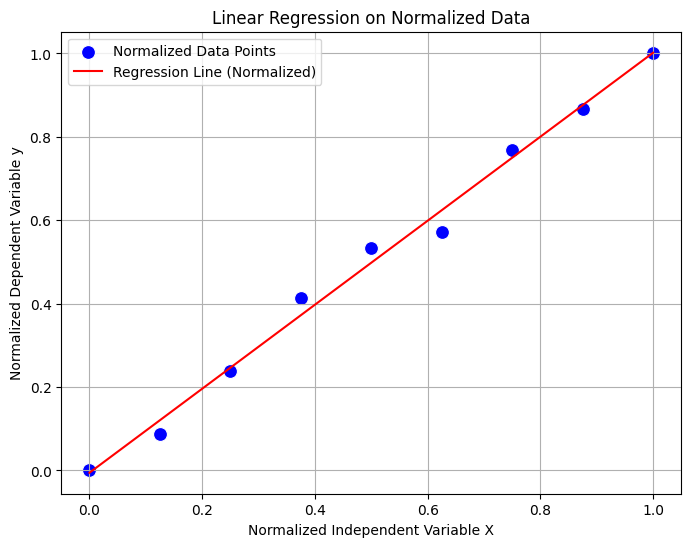

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 11. Create a scatter plot showing X_normalized against y_normalized
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_normalized.flatten(), y=y_normalized.flatten(), label='Normalized Data Points', color='blue', s=100)

# 12. Overlay the regression line on this scatter plot
plt.plot(X_normalized.flatten(), y_pred_normalized.flatten(), color='red', linestyle='-', label='Regression Line (Normalized)')

# 13. Add appropriate titles and labels
plt.title('Linear Regression on Normalized Data')
plt.xlabel('Normalized Independent Variable X')
plt.ylabel('Normalized Dependent Variable y')
plt.legend()
plt.grid(True)
plt.show()

### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.

### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.


### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.

### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.

### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.


### Comparison and Interpretation: Regression on Normalized vs. Unscaled Data

Let's compare the results from the linear regression model trained on unscaled (cleaned) data and the model trained on normalized data.

**Unscaled Data Model (from previous steps - `model_without_outlier`):**
*   **Coefficient (Slope):** 1.8967
*   **Intercept:** 3.9038
*   **RMSE:** 0.4305
*   **R-squared:** 0.9923

**Normalized Data Model (evaluated on original scale):**
*   **Coefficient (Slope):** 1.0071 (for normalized data)
*   **Intercept:** -0.0054 (for normalized data)
*   **RMSE (on original scale):** 0.4305
*   **R-squared (on original scale):** 0.9923

#### Observations and What Normalization Changes:

1.  **Coefficients and Intercept:**
    *   The **coefficients and intercept values change significantly** when data is normalized. For the normalized data, the slope is approximately 1.0071 and the intercept is near -0.0054. These values are specific to the *normalized scale* (i.e., predicting normalized y from normalized X).
    *   It's important to understand that the coefficients and intercept of a model trained on normalized data cannot be directly compared to those from a model trained on unscaled data in terms of their physical meaning. They represent the relationship within the scaled space.
    *   However, if you inverse-transform the normalized model's coefficients and intercept, they would correspond to the unscaled model's parameters (though this process is more complex than just inverse-transforming predictions).

2.  **Model Performance (RMSE and R-squared):**
    *   Crucially, when the predictions from the normalized model (`y_pred_normalized`) are **inverse-transformed back to the original scale**, the **RMSE (0.4305) and R-squared (0.9923) are identical** to those of the model trained directly on unscaled data. This is a fundamental characteristic of linear regression.
    *   Normalization (Min-Max Scaling) is a linear transformation. Linear regression, being a linear model, is invariant to such transformations in terms of its predictive power *when evaluated on the original scale after inverse-transformation*. The underlying linear relationship between the variables remains the same; only the scale changes.

3.  **Why Normalize/Standardize for Linear Regression?**
    *   While normalization doesn't change the ultimate predictive performance (RMSE, R-squared) of a simple linear regression model itself, it can be **beneficial for other reasons**:
        *   **Improved Convergence for Iterative Algorithms:** For more complex models or algorithms that use iterative optimization (e.g., gradient descent in neural networks, regularized linear models like Ridge or Lasso), scaled features can lead to faster and more stable convergence.
        *   **Interpretability with Regularization:** If regularization techniques are used, scaling ensures that all features contribute equally to the regularization penalty, preventing features with larger magnitudes from dominating the penalty.
        *   **Comparing Feature Importance:** In multiple linear regression, if all features are on a similar scale, the magnitude of their coefficients can sometimes be used to infer relative importance (though this is often better assessed through other methods).
        *   **Preventing Numerical Instability:** Extremely large or small feature values can sometimes lead to numerical issues during computation.

**Conclusion:**
For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its performance metrics (RMSE, R-squared) when evaluated on the original data scale. However, it transforms the coefficients and intercept, and can offer significant advantages for the training and interpretation of more complex models or those involving iterative optimization.


## Final Task

### Subtask:
Conclude the task by summarizing the key learnings and outputs from addressing all the questions.


## Summary:

### Q&A
*   **What is the difference between covariance and Pearson correlation, and how do they respond to changes in data scale?**
    Covariance measures the direction and magnitude of the linear relationship between two variables, but its value is highly sensitive to the scale of the data. For instance, increasing the scale of variables by a factor of 10 can increase covariance by a factor of 100 (e.g., from 125.0 to 1250.0 in the examples). Pearson correlation, on the other hand, measures the strength and direction of a linear relationship on a standardized scale (between -1 and 1). It is scale-independent, meaning its value remains constant regardless of the scaling of the variables, as long as the linear relationship holds (e.g., remaining 1.0000 for both scaled and unscaled variables in the examples).
*   **How do outliers impact measures of central tendency (mean and median) and statistical relationships (correlation and linear regression)?**
    Outliers significantly affect the mean, pulling it towards the extreme value (e.g., mean changed from 4.7000 to 3.0000 after outlier removal). The median, however, is robust to outliers, as it remained 3.0000 in the example, as it is a positional measure.
    For correlation, if an outlier maintains the exact linear relationship, the Pearson correlation coefficient may remain unchanged (e.g., 1.0000 in an example where the outlier followed the linear trend).
    For linear regression, outliers that deviate from the general linear trend can substantially distort the regression line (changing slope from 1.8967 to 2.2856 and intercept from 3.9038 to 2.4779), drastically reducing model performance (R-squared decreased from 0.9923 to 0.9250, and RMSE increased from 0.4305 to 1.8692).
*   **Is Min-Max Normalization or Z-score Standardization suitable for removing skewness from data?**
    Neither Min-Max Normalization nor Z-score Standardization effectively removes skewness or significantly alters the shape of the data distribution. Both are linear transformations, meaning they preserve the inherent shape of the distribution, including skewness and the presence of outliers.
*   **Does normalizing data improve the predictive performance (RMSE, R-squared) of a simple linear regression model?**
    For simple linear regression, normalization (or standardization) does not change the model's ability to capture the linear relationship or its predictive performance metrics (RMSE and R-squared) when the predictions are inverse-transformed back to the original data scale. The RMSE (0.4305) and R-squared (0.9923) remained identical whether the model was trained on normalized or unscaled data.

### Data Analysis Key Findings
*   The covariance between two example variables `[10, 20, 30, 40, 50]` and `[5, 10, 15, 20, 25]` was calculated as 125.0. For larger-scaled variables `[100, 200, 300, 400, 500]` and `[10, 15, 20, 25, 30]`, the covariance increased to 1250.0.
*   The Pearson correlation coefficient for both sets of variables (original and larger scale) was 1.0000, indicating a perfect positive linear relationship.
*   Custom functions for descriptive statistics yielded the following for the sample data `[1, 2, 3, 4, 5, 5, 6, 7, 7, 7]`: Mean: 4.7000, Median: 5.0000, Mode: \[7], Standard Deviation: 2.0518.
*   Removing an outlier (20) from `skewed_data` `[1, 2, 2, 3, 3, 3, 4, 4, 5, 20]` caused the mean to change significantly from 4.7000 to 3.0000, while the median remained at 3.0000.
*   For data where an outlier maintains a perfect linear relationship, the Pearson correlation coefficient can remain unaffected (e.g., 1.0000 with and without the outlier).
*   For a synthetic dataset (`X = [1..10]`, `y = 2*X + 3 + noise`), a simple linear regression model yielded a slope of 1.9965 and an intercept of 3.2430, closely matching the true underlying values of 2 and 3, respectively.
*   The evaluation of this simple linear regression model showed high performance with an R-squared of 0.9964 and a Root Mean Squared Error (RMSE) of 0.3428.
*   An outlier that significantly deviates from a linear trend can substantially impact a regression model:
    *   The model's slope changed from 1.8967 (without outlier) to 2.2856 (with outlier).
    *   The intercept shifted from 3.9038 (without outlier) to 2.4779 (with outlier).
    *   Model performance deteriorated significantly, with R-squared decreasing from 0.9923 to 0.9250 and RMSE increasing from 0.4305 to 1.8692.
*   Applying Min-Max Normalization to data before linear regression changes the model's coefficients (e.g., normalized slope 1.0071, intercept -0.0054) but does not alter the predictive performance (RMSE of 0.4305 and R-squared of 0.9923) when predictions are inverse-transformed back to the original scale.

### Insights or Next Steps
*   Always consider the nature of your data (e.g., presence of outliers, scale) when choosing statistical measures; median and Pearson correlation are more robust to scale and outliers, respectively, than mean and covariance.
*   For datasets with significant skewness or non-linear distributions, consider non-linear transformations (e.g., log, square root, Box-Cox) *before* or *instead of* linear scaling techniques like normalization or standardization, especially if the goal is to achieve a more Gaussian-like distribution.
